> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 3

## Outline

- Loading installed packages
- Inspect data
- Explore plot types

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_03_visualization_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Overview

As in the previous lab, you will work with the mtcars dataset, a classic collection of data about cars from the 1970s. It includes features such as miles per gallon (mpg), horsepower, weight, number of cylinders, and transmission type. Although the dataset is relatively small, it contains enough variety to explore meaningful relationships—like how a car’s weight impacts fuel efficiency or how horsepower relates to performance. Because it is clean, well-structured, and widely used in data science education, mtcars is an excellent starting point for learning Python tools like pandas, data visualization, and basic statistical analysis without the added complexity of messy real-world data.  

The MTCARS data consists of the following variables (columns):

| Column | Description                              |
| ------ | ---------------------------------------- |
| mpg    | Miles per gallon (fuel efficiency)       |
| cyl    | Number of cylinders                      |
| disp   | Displacement (cu. in.)                   |
| hp     | Gross horsepower                         |
| drat   | Rear axle ratio                          |
| wt     | Weight (1000 lbs)                        |
| qsec   | ¼ mile time                              |
| vs     | Engine type (0 = V-shaped, 1 = straight) |
| am     | Transmission (0 = automatic, 1 = manual) |
| gear   | Number of forward gears                  |
| carb   | Number of carburetors                    |


## 1. Load Libraries

In this assignment we will be using
- Pandas

We can pull sample data from
- statsmodels.api

In [15]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Import data into Pandas

In this case we will load data from the statsmodels.org library

MTCARS is a traditional dataset used for learning.



In [2]:
mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data
df = pd.DataFrame(mtcars)
df['carmodel'] = df.index
print(df)

                      mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
rownames                                                                       
Mazda RX4            21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
Mazda RX4 Wag        21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
Datsun 710           22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
Hornet 4 Drive       21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
Hornet Sportabout    18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   
Valiant              18.1    6  225.0  105  2.76  3.460  20.22   1   0     3   
Duster 360           14.3    8  360.0  245  3.21  3.570  15.84   0   0     3   
Merc 240D            24.4    4  146.7   62  3.69  3.190  20.00   1   0     4   
Merc 230             22.8    4  140.8   95  3.92  3.150  22.90   1   0     4   
Merc 280             19.2    6  167.6  123  3.92  3.440  18.30   1   0     4   
Merc 280C            17.8    6  167.6  1

## 3. View the Dataset Characteristics

In [3]:
#look at data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mpg       32 non-null     float64
 1   cyl       32 non-null     int64  
 2   disp      32 non-null     float64
 3   hp        32 non-null     int64  
 4   drat      32 non-null     float64
 5   wt        32 non-null     float64
 6   qsec      32 non-null     float64
 7   vs        32 non-null     int64  
 8   am        32 non-null     int64  
 9   gear      32 non-null     int64  
 10  carb      32 non-null     int64  
 11  carmodel  32 non-null     object 
dtypes: float64(5), int64(6), object(1)
memory usage: 3.2+ KB


In [4]:
#look at top rows
df.head(10)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,carmodel
rownames,,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,Mazda RX4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,Mazda RX4 Wag
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,Datsun 710
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,Hornet 4 Drive
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,Hornet Sportabout
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1,Valiant
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4,Duster 360
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2,Merc 240D
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2,Merc 230


In [5]:
#get a summary of the dataset
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000



## 4. Create basic charts

Pandas makes it easy to create data visualizations directly from a DataFrame using built-in charting functions. With simple commands like df.plot(), you can quickly generate line charts, bar graphs, histograms, and more without needing a lot of extra code. These visualizations help you see patterns, trends, and relationships in your data that might not be obvious from raw numbers alone. By learning how to use pandas’ plotting tools, you can turn your analysis into clear, visual insights that are easier to understand and communicate.

Below are examples of the following chart type:
- Line chart
- Bar chart
- Histogram
- Box plot
- Scatter plot




<Axes: title={'center': 'MPG by Car'}, xlabel='carmodel'>

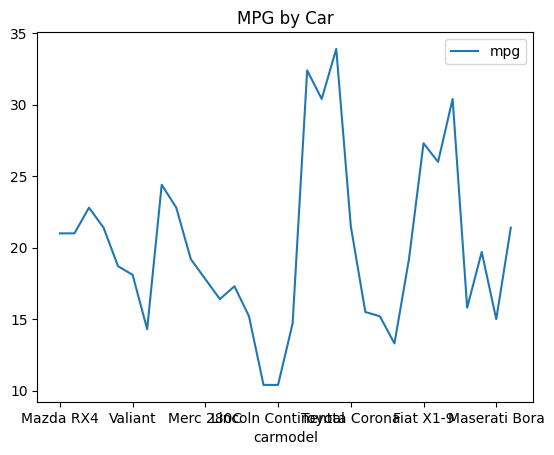

In [6]:
#Line chart
df.plot(x='carmodel', y='mpg', kind='line', title="MPG by Car")

<Axes: title={'center': 'MPG by Car'}, xlabel='carmodel'>

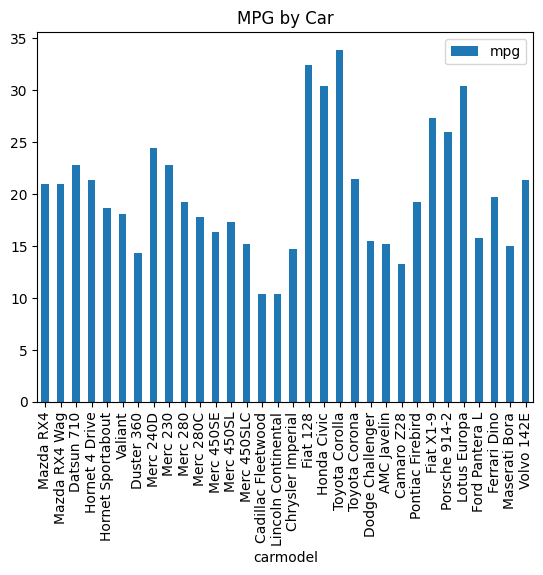

In [7]:
#Bar chart
df.plot(x='carmodel', y='mpg', kind='bar', title="MPG by Car")

<Axes: title={'center': 'MPG Distribution'}, ylabel='Frequency'>

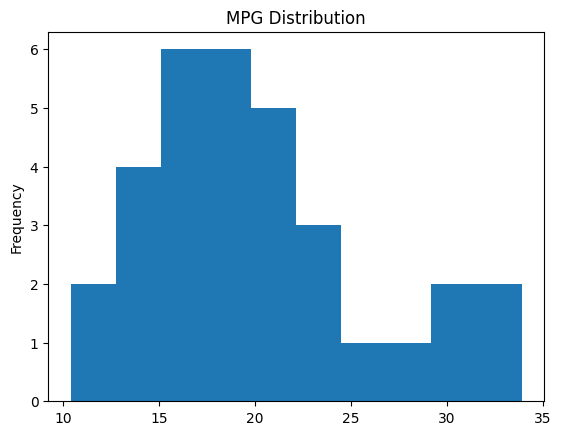

In [8]:
#Histogram
df['mpg'].plot(kind='hist', bins=10, title="MPG Distribution")

<Axes: title={'center': 'Miles Per Gallon'}>

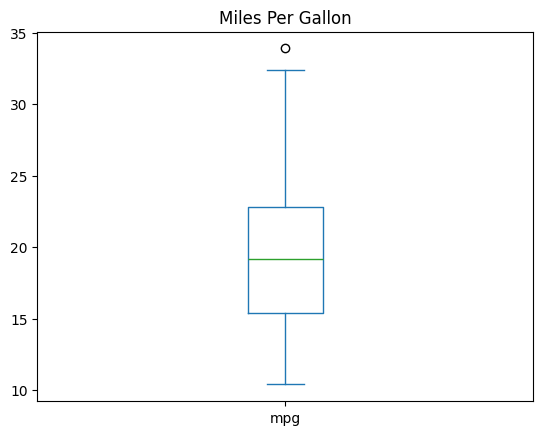

In [9]:
#Boxplot
df['mpg'].plot(kind='box', title = 'Miles Per Gallon')

<Axes: xlabel='mpg', ylabel='hp'>

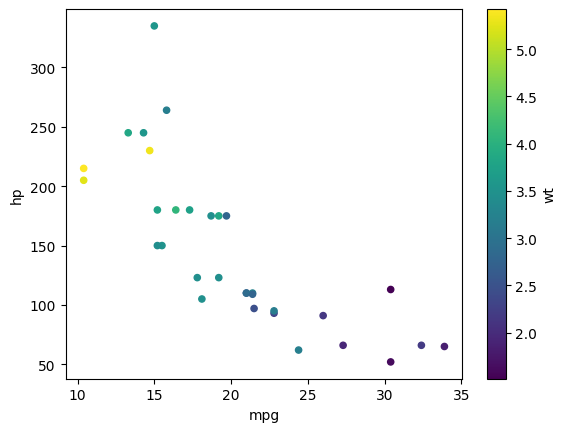

In [10]:
#Scatter plot
df.plot.scatter(x='mpg',y='hp',c='wt')

### 5. Create Additional Charts

You are welcome to import additional libraries for these tasks, but you should move the `import` lines into the top section of this lab.   And if possible, use Pandas to do them.  

When working in Jupyter notebooks, it’s important to keep your code clean, organized, and intentional. A well-structured notebook—with clear sections, meaningful comments, and only the necessary code—makes your work easier to understand, debug, and share with others (including your future self). It can be tempting to rely on AI to generate large chunks of code, but this often leads to unnecessary complexity, repeated imports, or the use of unfamiliar libraries that make your work harder to follow. Instead, focus on writing code you understand and only importing what you actually need. This helps you build real skills, keeps your notebook efficient, and ensures that you can explain and adapt your work when it matters.

#### 🔧 Do the following
- 1 Create a pie chart showing the count of cars by transmission type.  Display labels showing the percentage of each transmission type.  
- 2 Create a bar chart of cars and HP, with different colors for each car model (you are allowed to import another library, other than Pandas to do this)
- 3 Create a scatter plot of wt (weight) vs. mpg.
- 4 Create a bar chart showing the average mpg for each cyl.
- 5 Plot a histogram of the weight column.

<Axes: title={'center': 'Number of Cars by Transmission Type'}>

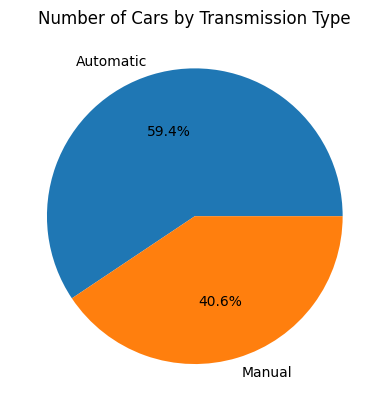

In [12]:
transmission_counts = df['am'].value_counts()
transmission_counts.index = transmission_counts.index.map({0: 'Automatic', 1: 'Manual'})

transmission_counts.plot(kind='pie', autopct='%1.1f%%', title='Number of Cars by Transmission Type', ylabel='')

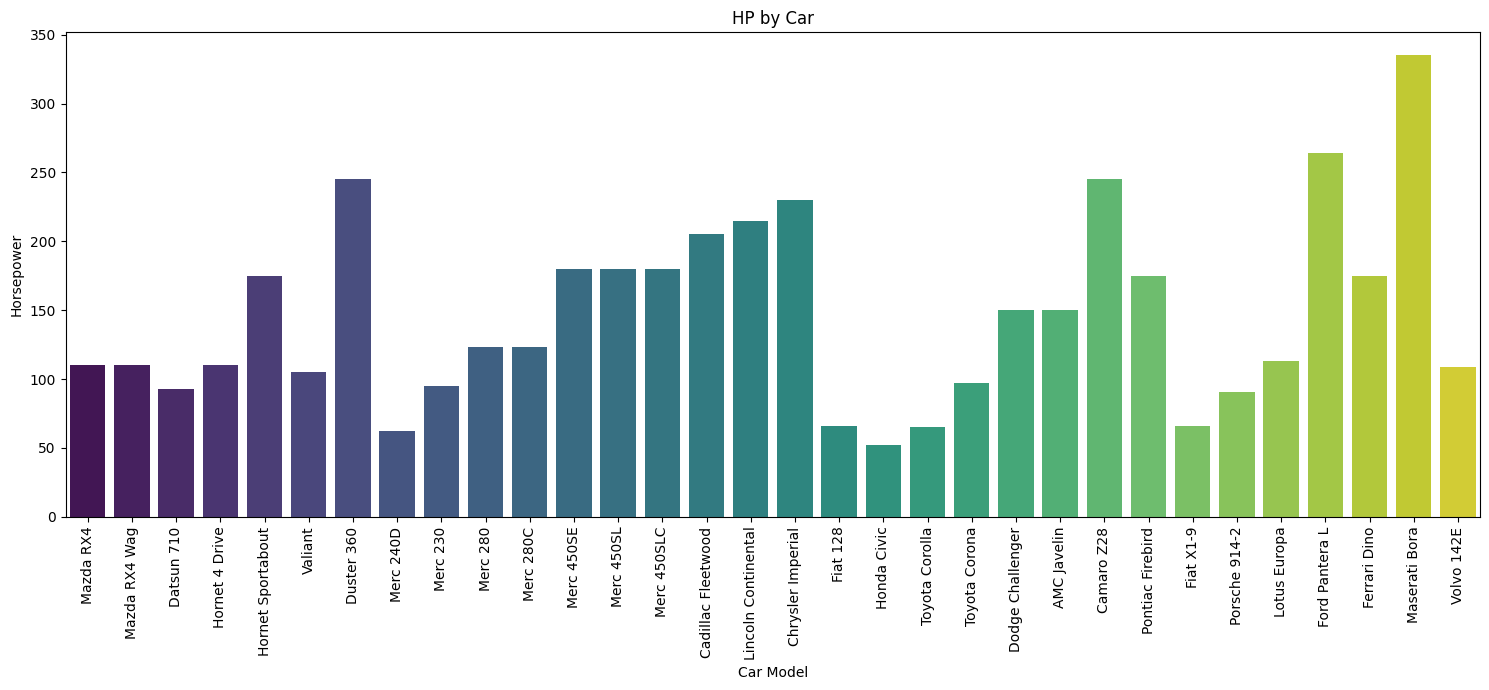

In [17]:
#Bar chart 🔧
plt.figure(figsize=(15, 7)) # Adjust figure size for better readability
sns.barplot(x='carmodel', y='hp', data=df, hue='carmodel', dodge=False, palette='viridis')
plt.title("HP by Car")
plt.xlabel("Car Model")
plt.ylabel("Horsepower")
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.legend([],[], frameon=False) # Hide legend as each bar is colored by its own label
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

<Axes: title={'center': 'Weight vs. MPG'}, xlabel='wt', ylabel='mpg'>

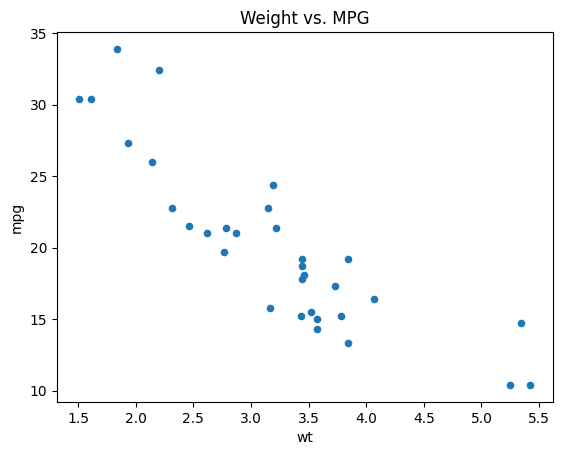

In [18]:
#Scatter plot 🔧
df.plot.scatter(x='wt', y='mpg', title='Weight vs. MPG')

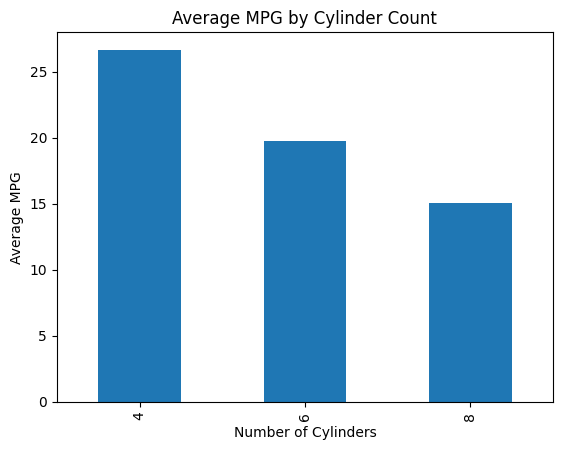

In [19]:
#Bar chart 🔧
df.groupby('cyl')['mpg'].mean().plot(kind='bar', title='Average MPG by Cylinder Count', xlabel='Number of Cylinders', ylabel='Average MPG')
plt.show()

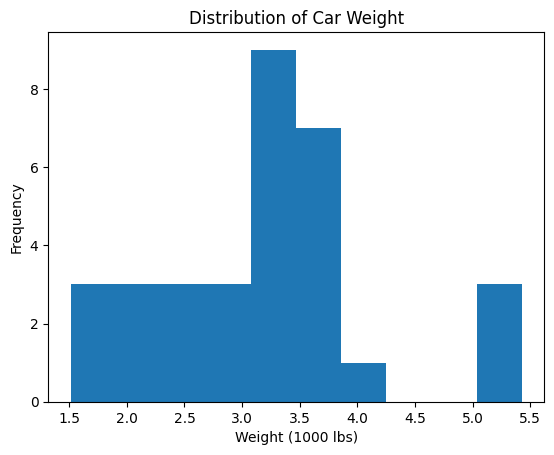

In [21]:
#Histogram 🔧
df['wt'].plot(kind='hist', bins=10, title='Distribution of Car Weight', xlabel='Weight (1000 lbs)', ylabel='Frequency')
plt.show()

### 6: Reflection
(100 words or less per question)
- Referring to the first graph you made (i.e. the pie chart) which transmission type has the larger frequency? (i.e. which transmission type has the largest slice of the pie?)  
- Referring to the last graph you made (i.e. the histogram) which weight is the most frequent?
- By looking at the charts above, you can see which variables have a relationship with MPG.  If you were to give advice to a manufacturer on how to optimize MPG, what changes to a car would you suggest, based on the charts you have created?


### ✍️ Your Response: 🔧
1. Automatic transmissions have the larger frequency, taking up 59.4% of the dataset.

2. The most frequent weight range is approximately 3.1 to 3.5 thousand pounds, meaning cars weighing about 3,100–3,500 pounds appear most often.

3. I would recommend reducing the car’s weight and using fewer cylinders because the charts show that lighter cars and four-cylinder vehicles generally achieve higher MPG. Manufacturers could also avoid unnecessary horsepower. Overall, designing a lighter vehicle with a smaller, less powerful engine would likely improve MPG.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [22]:
!jupyter nbconvert --to html "lab_03_visualization_intro.ipynb"

[NbConvertApp] Converting notebook lab_03_visualization_intro.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 679191 bytes to lab_03_visualization_intro.html


## Submit your assignment

- Make sure that all of your output is shown.  If you get the “unable to render code block” error, try refreshing the cache or downloading raw data to manually upload into Colab as a workaround.
- Upload your HTML file to Canvas
- Optionally, save your file in your own GitHub account for future use
